# Convex hull from Materials Project

Fetches a binary chemical system from the Materials Project, computes a per-structure energy for every entry with `atomistics`' in-process LAMMPS lib calculator (run via a nested `executorlib` allocation), and plots the resulting mixing-energy convex hull.

Requires the `atomistics`, `materials_project`, `plotting`, and `executor` extras:
```
pip install -e .[atomistics,materials_project,plotting,executor]
```
The example potential below is fetched via `lammpsparser.get_potential_by_name`, which needs the `iprpy-data` conda package installed in the active environment:
```
conda install -c conda-forge iprpy-data
```

In [1]:
import sys
from pathlib import Path

# Add project root to path for imports
PROJECT_ROOT = next(
    (parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / "pyproject.toml").is_file()),
    Path.cwd(),
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

## Imports

In [2]:
import os

from executorlib import SlurmClusterExecutor
from lammpsparser import get_potential_by_name

from phase_diagram_workflows.phase_diagram.convex_hull import (
    fetch_structures_and_energies,
    analyze_convex_hull,
)

## Setup: API key and potential

In [3]:
# Get your own key from https://next-gen.materialsproject.org/api
api_key = os.environ.get("MP_API_KEY", "YOUR_MP_API_KEY")

# Requires the iprpy-data conda package (see the notebook intro above).
resource_path = os.path.join(sys.prefix, "share", "iprpy")
potential_df = get_potential_by_name("1998--Liu-X-Y--Al-Mg--LAMMPS--ipr1", resource_path=resource_path)
potential_df = potential_df.to_frame().transpose()
# atomistics' LAMMPS input builder expects each Config line newline-terminated
potential_df["Config"] = potential_df["Config"].apply(lambda cfg: [s if s.endswith("\n") else s + "\n" for s in cfg])

/cmmc/ptmp/pchilaka/mamba/envs/lammps_mdmc/lib/python3.12/site-packages/lammpsparser/potential.py:326: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pot["Config"] = config_lst


## Step 1: fetch structures + compute energies

One outer SLURM allocation runs an inner executor that fans its cores out across all structures -- one outer job total, instead of one job per structure. Adjust `queue` and `pysqa_config_directory` for your own cluster. The outer allocation's CPU reservation is sized automatically from `inner_max_workers` and `inner_resource_dict` -- no need to compute or repeat that yourself.

In [4]:
inner_max_workers = 64      # structures processed concurrently
inner_threads_per_core = 2  # cores claimed per structure

structures_df = fetch_structures_and_energies(
    elements=["Al", "Mg"],
    api_key=api_key,
    potential_df=potential_df,
    outer_executor_cls=SlurmClusterExecutor,
    outer_resource_dict={
        "queue": "cmmg",
        "cores": 1,
        "run_time_max": 1200,
    },
    inner_resource_dict={"cores": 1, "threads_per_core": inner_threads_per_core},
    inner_max_workers=inner_max_workers,
    cache_directory="executorlib_cache_convex_hull",
    pysqa_config_directory="/u/system/SLES12/soft/pyiron/dev/pyiron-resources-cmmc/queues",
)
structures_df.head()

Retrieving SummaryDoc documents:   0%|          | 0/10 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/32 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/9 [00:00<?, ?it/s]

/cmmc/ptmp/pchilaka/mamba/envs/lammps_mdmc/lib/python3.12/site-packages/executorlib/executor/slurm.py:192: UserWarning: The following keys are not recognized and cannot be validated: ['queue', 'run_time_max']
  validate_resource_dict_with_optional_keys(resource_dict=resource_dict)


,dos_energy_up,types_of_magnetic_species,total_magnetization_normalized_vol,has_reconstructed,is_magnetic,weighted_surface_energy_EV_PER_ANG2,possible_species,material_id,deprecated,last_updated,...,fields_not_requested,unavailable_fields,structure_ase,crystal_system,space_group,material_id_underscore,fractions,x,atoms_relaxed,energy_per_atom_calc
0,0.0,[],0.000000e+00,False,False,0.049732,[Al0+],mp-134,False,2023-10-07 09:06:12.726000+00:00,...,[prop_origins],[],"(Atom('Al', [np.float64(0.0), np.float64(0.0),...",Cubic,Fm-3m,mp_134,"{'Al': 1.0, 'Mg': 0.0}",0.0,"(Atom('Al', [np.float64(0.0008205823045303929)...",-3.359966
1,0.0,[],0.000000e+00,None,False,NaN,[Al0+],mp-998860,False,2023-10-07 05:01:21.056000+00:00,...,[prop_origins],[],"(Atom('Al', [np.float64(0.0), np.float64(0.0),...",Cubic,Im-3m,mp_998860,"{'Al': 1.0, 'Mg': 0.0}",0.0,"(Atom('Al', [np.float64(0.030356098321648557),...",-3.275787
2,0.0,[],1.572780e-09,None,False,NaN,[Al0+],mp-1183144,False,2022-06-10 18:15:57.821000+00:00,...,[prop_origins],[],"(Atom('Al', [np.float64(0.0), np.float64(0.0),...",Hexagonal,P6_3/mmc,mp_1183144,"{'Al': 1.0, 'Mg': 0.0}",0.0,"(Atom('Al', [np.float64(-0.01951532531611917),...",-3.341078
3,0.0,[],1.063355e-09,None,False,NaN,[Al0+],mp-1239196,False,2022-06-14 17:22:34.724000+00:00,...,[prop_origins],[],"(Atom('Al', [np.float64(4.94999999989254e-07),...",Tetragonal,I4/mmm,mp_1239196,"{'Al': 1.0, 'Mg': 0.0}",0.0,"(Atom('Al', [np.float64(-0.013265273229916386)...",-2.806543
4,NaN,[],4.829420e-06,None,False,NaN,[Al0+],mp-1244953,False,2019-07-02 00:27:48.141000+00:00,...,[prop_origins],[],"(Atom('Al', [np.float64(12.213051659842796), n...",Triclinic,P1,mp_1244953,"{'Al': 1.0, 'Mg': 0.0}",0.0,"(Atom('Al', [np.float64(11.341875844315245), n...",-3.293251


## Step 2: convex hull

`backend='matplotlib'` is also available for a static, publication-style version of the same plot.

The y-axis auto-scales to all the data by default -- no `yrange` needed for
well-behaved data. This particular fetch has a handful of badly-relaxed
outliers up around 0.25-0.8 eV/atom (this EAM potential clearly doesn't
handle every MP structure it's handed), which would squash the
actually-interesting hull region into a thin band at the bottom under plain
auto-scaling. `yrange=(-0.05, 0.15)` below is a deliberate, explicit override
for that -- pass your own `(lo, hi)` for any plot where auto-scaling doesn't
look right, e.g. to keep two plots on the same scale for comparison.

In [5]:
fig, structures_df_hull = analyze_convex_hull(structures_df, element="Mg", yrange=(-0.05, 0.15))
fig.show()
structures_df_hull

,dos_energy_up,types_of_magnetic_species,total_magnetization_normalized_vol,has_reconstructed,is_magnetic,weighted_surface_energy_EV_PER_ANG2,possible_species,material_id,deprecated,last_updated,...,unavailable_fields,structure_ase,crystal_system,space_group,material_id_underscore,fractions,x,atoms_relaxed,energy_per_atom_calc,mixing_energy
0,0.0,[],0.000000e+00,False,False,0.049732,[Al0+],mp-134,False,2023-10-07 09:06:12.726000+00:00,...,[],"(Atom('Al', [np.float64(0.0), np.float64(0.0),...",Cubic,Fm-3m,mp_134,"{'Al': 1.0, 'Mg': 0.0}",0.000000,"(Atom('Al', [np.float64(0.0008205823045303929)...",-3.359966,0.000000
1,NaN,[],0.000000e+00,None,False,NaN,[],mp-1094116,False,2021-05-22 01:09:52.988000+00:00,...,[],"(Atom('Mg', [np.float64(-2.72002690002418), np...",Hexagonal,P6_3/mmc,mp_1094116,"{'Al': 0.6666666666666666, 'Mg': 0.33333333333...",0.333333,"(Atom('Mg', [np.float64(-2.7205483879551284), ...",-2.779871,-0.036561
2,NaN,[],1.759420e-10,None,False,NaN,[],mp-2151,False,2023-10-07 07:43:40.044000+00:00,...,[],"(Atom('Mg', [np.float64(0.0), np.float64(0.0),...",Cubic,I-43m,mp_2151,"{'Al': 0.41379310344827586, 'Mg': 0.5862068965...",0.586207,"(Atom('Mg', [np.float64(-0.02154921401015692),...",-2.311842,-0.036341
3,0.0,[],0.000000e+00,False,False,0.036823,[Mg0+],mp-153,False,2023-10-07 21:59:09.731000+00:00,...,[],"(Atom('Mg', [np.float64(-1.2526783602348875e-0...",Hexagonal,P6_3/mmc,mp_153,"{'Al': 0.0, 'Mg': 1.0}",1.000000,"(Atom('Mg', [np.float64(-0.012718301117423222)...",-1.509997,0.000000


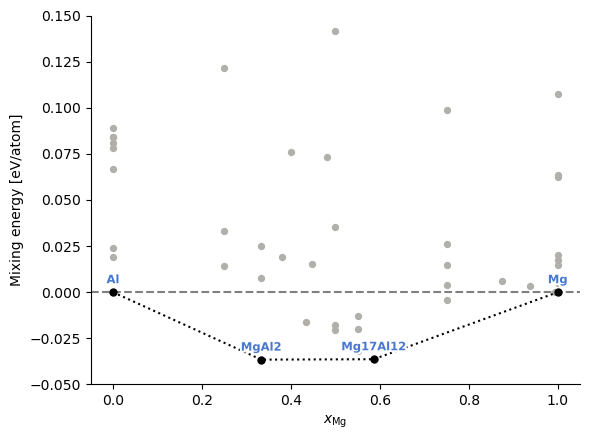

In [6]:
fig_static, ax, _ = analyze_convex_hull(structures_df, backend="matplotlib", element="Mg", yrange=(-0.05, 0.15))

## Step 3: compare against Materials Project's own DFT hull

`structures_df` already includes `formation_energy_per_atom` -- Materials
Project's own hull-consistent formation energy, present for free from the
same fetch in Step 1 (`fields=None` there pulls every field, this one just
went unused until now). This is the literal value MP's API returns and
their website is built from -- verified against MP's own `is_stable`/
`energy_above_hull` fields, not something re-derived locally. (An earlier
version of this notebook re-derived a hull via `get_entries_in_chemsys`
restricted to GGA/GGA+U entries; that disagreed with MP's real numbers by
~10-20 meV/atom for some compounds, enough to misjudge which compositions
are stable. Don't do that -- this field is already correct.) Passing it as
`dft_energy_col` overlays it as a second, dashed hull for comparison
against this potential's own hull.

Text(0.5, 1.0, 'With Materials Project DFT overlay')

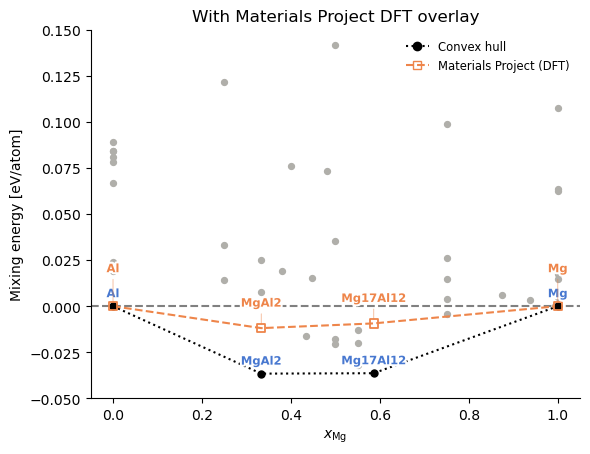

In [7]:
fig_with_dft, ax_with_dft, _ = analyze_convex_hull(
    structures_df, backend="matplotlib", element="Mg", dft_energy_col="formation_energy_per_atom",
    yrange=(-0.05, 0.15),
)
ax_with_dft.set_title("With Materials Project DFT overlay")